# Day25_Sklearn_traindata_testdata_overfitting_underfitting
(03-apr-24)

1.	Define the Problem: Identify the problem and goals.
2.	Collect and Prepare Data: Gather, clean, and preprocess the data,scatterplot, corrolation, boxplot. - EDA
3.	Split the Data: Divide into training and testing sets (and optionally validation).
4.	Choose the Algorithm and Build the model : Select the right model for the task.
5.	Train the Model: Fit the model to the training data.
6.	Evaluate the Model: Test the model's performance using the test set,MSE,RMSE,Rsquare,accuracy,precision,recall,residual analysis(meam=0,normally         distributed,constant variance, outlier removal(Partial regressor plot(cooks factor,highinfluence point))).
7. Repeat step 5,6th if it is required
8.	Tune Hyperparameters: Optimize the model's hyperparameters for better performance.
9.	Handle Overfitting/Underfitting: Adjust the model to improve generalization.
10.	Deploy the Model: Put the model into production for real-time predictions.
11.	Monitor and Maintain: Continuously monitor and update the model as needed.


# Step 1 - Define the problem

Define the cars mileage

# Step 2 - Collect and Prepare Data

In [215]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot

In [17]:
data = pd.read_csv('mycars.csv')
data

## step 2.1 Examine the data

In [15]:
data.head()

,MPG,HP,VOL,SP
0,53.700681,49,89,104.185353
1,50.013401,55,92,105.461264
2,50.013401,55,92,105.461264
3,45.696322,70,92,113.461264
4,50.504232,53,92,104.461264


In [19]:
data.shape

(77, 4)

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MPG     77 non-null     float64
 1   HP      77 non-null     int64  
 2   VOL     77 non-null     int64  
 3   SP      77 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.5 KB


In [27]:
data.columns

Index(['MPG', 'HP', 'VOL', 'SP'], dtype='object')

In [29]:
data.describe()

,MPG,HP,VOL,SP
count,77.000000,77.000000,77.000000,77.000000
mean,34.776310,108.506494,100.402597,119.363923
std,9.049927,41.962585,20.531913,10.577954
min,12.101263,49.000000,50.000000,99.564907
25%,28.860225,81.000000,91.000000,113.484609
50%,35.404192,96.000000,101.000000,117.598513
75%,40.050000,130.000000,113.000000,124.715241
max,53.700681,245.000000,160.000000,158.300669


### Step 2.1.1 - check x can be used to predict Y 

#### step 2.1.1.1 Scatter plot

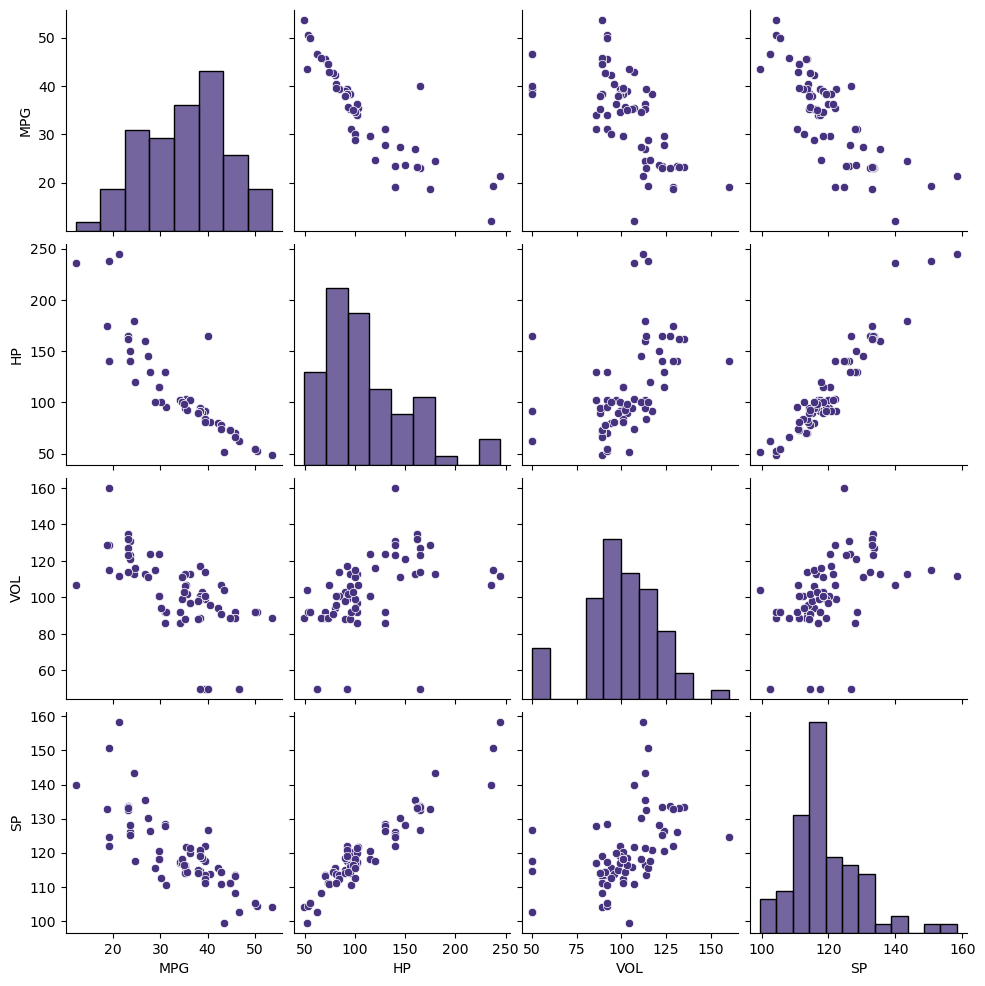

In [33]:
sns.set_palette('viridis') # for colour - optional
sns.set_style='whitegrid' #optinal
sns.pairplot(data) # mandatory
plt.show()

- Almost all the features are having correlation(negative) with target column i.e.MPEG, means all are relavent ferature to predict the Y
- But there are some idepenedent feature(WT vs VOL) are higly corelated with each, ideally which should not have. So id does not make any sense to
  use both of the column in analysis, going forward we will drop one

#### 2.1.1.2 Correlation matrix

In [41]:
corr=data.corr()
print(corr)
print(type(corr))

          MPG        HP       VOL        SP
MPG  1.000000 -0.882314 -0.636420 -0.804580
HP  -0.882314  1.000000  0.464684  0.953300
VOL -0.636420  0.464684  1.000000  0.474343
SP  -0.804580  0.953300  0.474343  1.000000
<class 'pandas.core.frame.DataFrame'>


In [43]:
print(corr['MPG'].sort_values(ascending=True)) # only with respect to target column

HP    -0.882314
SP    -0.804580
VOL   -0.636420
MPG    1.000000
Name: MPG, dtype: float64


<Axes: >

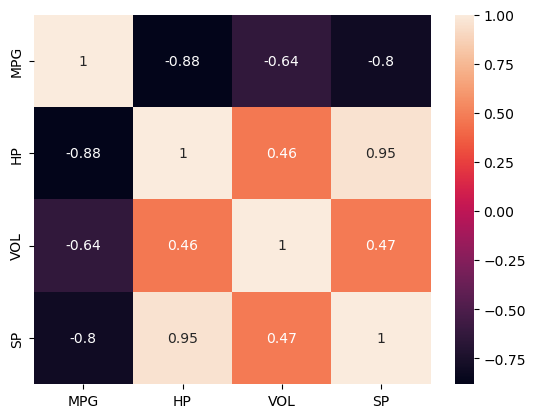

In [45]:
sns.heatmap(corr,annot=True) # Annot will provide numbers

C:\Users\Pandhari\AppData\Local\Temp\ipykernel_27908\2970421101.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['MPG'])


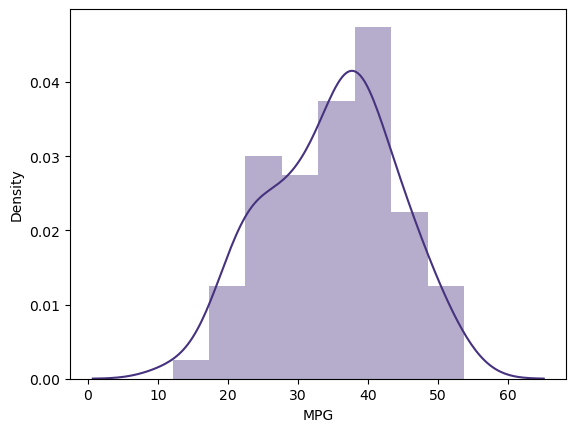

In [50]:
sns.distplot(data['MPG'])
plt.show()

#### step 2.1.1.4 Transform the date type if required

#### step 2.1.1.5 replace null value

# Step 3 - Split the Data

## Step 3.1 - find out independent and dependent variable 

- dpendent varaible - Y - MPG
- independent varaible x - HP,VOL,SP

## Step 3.2 split the data into X-train and Y-train

In [59]:
x = data.iloc[:,1:]
y = data.iloc[:,0]

In [65]:
print(x.head(3))


   HP  VOL          SP
0  49   89  104.185353
1  55   92  105.461264
2  55   92  105.461264


In [67]:
print(y.head(3))

0    53.700681
1    50.013401
2    50.013401
Name: MPG, dtype: float64


In [72]:
from sklearn.model_selection import train_test_split

In [140]:
x_train,x_Test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# random_State=42 - to avoide the the change in output for every execution

In [142]:
x_train.shape,x_Test.shape,y_train.shape,y_test.shape

((61, 3), (16, 3), (61,), (16,))

# Step 4 - Choose the Algorithm and Build the model

- As target variable is number and continuous in nature and we have multiple independent variable. So we can multilinear regeression model

In [146]:
from sklearn.linear_model import LinearRegression

In [148]:
model=LinearRegression() # Model Initialization: You don't pass x_train and y_train directly when initializing the model. You only need to initialize the model with LinearRegression().


In [150]:
# model1=LinearRegression(x_train,y_train,data=data)
# model.fit() -- we cant do like this. first create a model with empty object and then pass data while fitting

# Step 5 -Train the Model

In [153]:
model.fit(x_train,y_train) # You fit the model using the .fit() method with your training data (x_train, y_train). This step trains the linear regression model.

LinearRegression()

# Step 6 - Evaluate the Model

## Step 6.1 - predict the values for training data(x_train) - yhat_train

In [157]:
yhat_train=model.predict(x_train)
yhat_train

array([41.15993281, 43.31283364, 37.90243055, 38.44128002, 36.30110032,
       34.94611865, 34.45516129, 41.51207681, 30.51214342, 26.94058359,
       37.58969964, 46.01432042, 25.24298145, 36.0912469 , 23.59667947,
       32.35988654, 10.23635286, 38.61053985, 25.03806305, 43.80928534,
       36.60542143, 41.61669171, 28.97753938, 43.01546453, 45.19269637,
       37.20015961, 46.01432042, 28.66098727, 43.19570805, 38.7139742 ,
       22.39941699, 34.9251982 , 34.77685887, 13.53882678, 41.61669171,
       38.95225699, 35.63997984, 37.16804249, 35.04989947, 39.63075638,
       37.42419433, 15.71960015, 32.35988654, 45.19269637, 37.03208032,
       20.52386561, 32.99695572, 26.03596569, 22.87967032, 37.20015961,
       36.24403111, 43.19570805, 30.08005691, 38.65224722, 43.19570805,
       39.78145675, 38.95225699, 28.7024842 , 22.6967861 , 42.03897249,
       32.35988654])

## Step 6.2 - Check the measure for x_train data and evaluate the model

In [160]:
from sklearn.metrics import mean_squared_error,r2_score
train_mse=mean_squared_error(y_train,yhat_train)
print(train_mse)
train_rmse=np.sqrt(train_mse)
print(train_rmse)
train_r2=r2_score(y_train,yhat_train)
print(train_r2)

10.669138491045693
3.266364721069234
0.8604375230622243


- The model has rsquare value is 0.87, so we can consider this model is good model

## Step 6.3 - Check the measure for x_test data and evaluate the model

In [164]:
yhat_test=model.predict(x_Test)

In [166]:
test_mse=mean_squared_error(y_test,yhat_test)
print(test_mse)
test_rmse=np.sqrt(test_mse)
print(test_rmse)
test_r2=r2_score(y_test,yhat_test)
print(test_r2)

12.281528493298723
3.504501176101775
0.8733416589640454


In [ ]:
- Test r2 and Train r2 are in same range so model is good ant overfitting or underfitting.
- ANd MPG mean is 34 and r2 is 3.5, so we can conclude that error made by model is 10% of real value which is gd

## 6.4 Residual analysis

In [171]:
train_error=y_train-yhat_train
train_error

9     1.139145
5     2.383489
34    1.629202
22   -0.130674
30    3.130135
        ...   
20   -0.541254
60   -1.348219
71    0.506783
14    3.695920
51   -2.729951
Name: MPG, Length: 61, dtype: float64

In [173]:
test_error=y_test-yhat_test
test_error

4     7.253749
35    0.235999
10    3.036143
0     9.121005
45   -1.404836
47   -0.572288
66   -1.065098
53   -0.983194
50   -2.729951
28    3.917293
68   -0.172991
74   -0.877891
18    1.277832
12   -0.981574
58   -4.485480
33    0.839345
Name: MPG, dtype: float64

In [183]:
type(test_error)

pandas.core.series.Series

### Step 6.4.2 Residual should be normally distributed - we can use KDE plot and Q-Q plot to check normal distribution

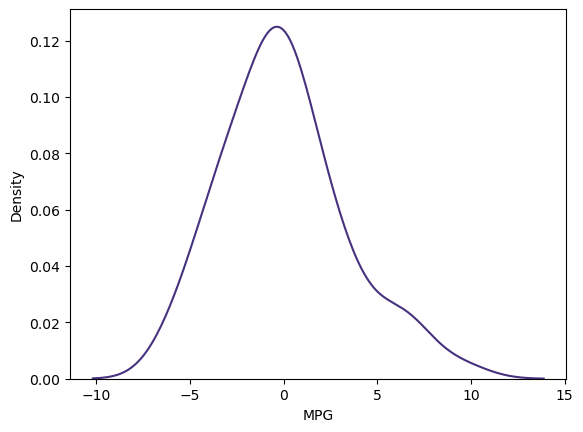

In [194]:
sns.kdeplot(train_error) # this plot shows residuals are almost normally distributed
plt.show()
# with statsmode residual we will find out by cars_model.resid
# with sms we find residual by train_error=y_train-yhat_train

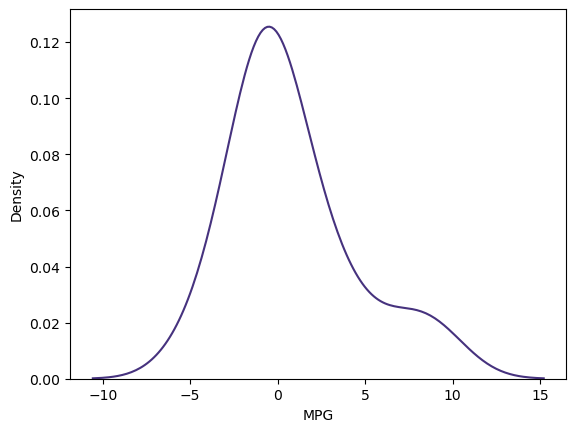

In [196]:
sns.kdeplot(test_error) # this plot shows residuals are almost normally distributed
plt.show()

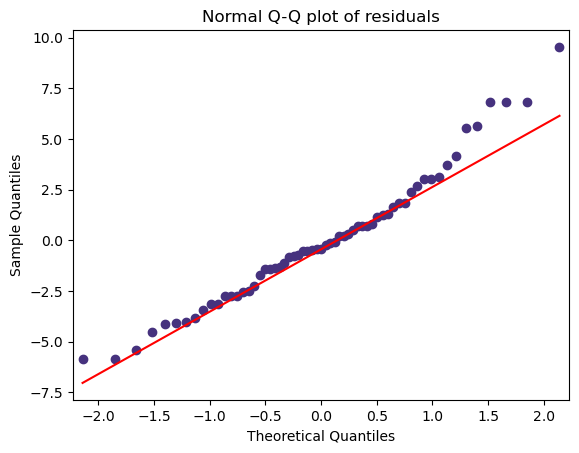

In [206]:
qqplot=sm.qqplot(train_error,line='q') #line=45 to draw the diagonal value
plt.title('Normal Q-Q plot of residuals')
plt.show() 

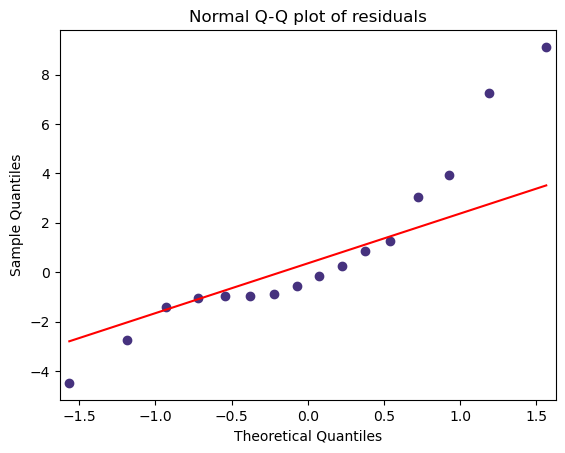

In [208]:
qqplot=sm.qqplot(test_error,line='q') #line=45 to draw the diagonal value
plt.title('Normal Q-Q plot of residuals')
plt.show() 

### Step 6.4.3 Residual Vs regressor - Partial regressor plot

In [217]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model,'SP',fig=fig)
plt.show()

AttributeError: 'LinearRegression' object has no attribute 'model'

<Figure size 1500x800 with 0 Axes>

# Step 7 - Repeat step 5,6th if it is required

# Step 8 - Tune Hyperparameters

# Step 9 - Handle Overfitting/Underfitting